In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart


# --------------------------------------------------------
# 0. Setting up the environment and importing necessary libraries
# --------------------------------------------------------
# This script implements the sign restriction approach by Uhlig (2005) to identify structural shocks in a VAR model.
# The script is optimized for a local environment where the data is stored in an Excel file named 'uhligdata.xls'.
# You have to ensure that the 'uhligdata.xls' file is in the same directory as this script for it to run successfully.

# ====================================================================================
# 1. DATA PREPARATION FOR THE LOCAL ENVIRONMENT: Reproducing Uhlig's (2005) Fig.6.
# ====================================================================================
# Importing data from the local file 'uhligdata.xls' located in the same directory as this script.
# We save the data in a DataFrame and drop any rows with missing values to ensure clean data for analysis.
filepath = 'uhligdata.xls'
df = pd.read_excel(filepath).dropna()


# In this code block, we select the variables that must be transformed using the logarithm. 
# We apply the natural logarithm to these variables and multiply by 100 to convert them into percentage terms. 
# This transformation is suggested by Uhlig (2005: p. 392) where he clarifies that he did NOT take the logarithm of the federal funds rate (FEDFUNDS). 
# The reason is technical: the federal funds rate can take values close to zero, which would lead to issues with the logarithm.
cols_to_log = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'BOGNONBR', 'TOTRESNS']
for col in cols_to_log:
    df[col] = np.log(df[col]) * 100


# These two lines of code prepare the data for the VAR model. We define the order of the columns 
# we want to use and extract their values into a NumPy array called Y_raw.
ordered_cols = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'FEDFUNDS', 'BOGNONBR', 'TOTRESNS']
Y_raw = df[ordered_cols].values


# The next code block constructs the lagged variables for the VAR model. We set the number of lags (p) to 12, which is a common choice for monthly data.
# First, we calculate the number of observations (T) after accounting for the lags. We then create a new matrix X that will hold the lagged values of the variables.
# T_raw is the total number of observations in Y_raw, and we subtract p to get the number of usable observations for the VAR model. 
# The line Y = Y_raw[p:] creates the dependent variable matrix Y, which contains the values of the variables starting from the (p+1)-th observation, 
# so we have of course lost the first p observations due to the lag structure. The next line, X = np.zeros((T, m * p)), 
# initializes the matrix X with zeros, where T is the number of observations and m is the number of variables. The for loop fills the matrix X with the lagged values of Y_raw.
# Note that in Python, we have to have a huge matrix with all the lagged explanatory variables. 
# The left side, X[:, i*m : (i+1)*m], describes where to allocate the lagged values. The : means that in each round in the for loop, 
# we fill all rows of X for the columns corresponding to the i-th lag of all variables. As p = 12, i ranges from 0 to 11. The part i*m : (i+1)*m 
# defines the column indices for the i-th lag of all m variables. For instance, when i = 0, we fill the columns from 0 to m-1 with the first lag of all variables, 
# when i = 1, we fill the columns from m to 2*m-1 with the second lag, and so on.
# The right side, Y_raw[p - i - 1 : T_raw - i - 1], selects the appropriate lagged values from Y_raw. For the first six columns of X (i = 0), 
# we take the values from Y_raw starting from the p-th observation up to T_raw - 1, so we drop the upper 11 rows and the last row from Y_raw. 
# For the next six columns (i = 1), we drop the upper 10 rows and the last two rows from Y_raw, and so on. This way, we fill the matrix X with the lagged values of the variables,
# ensuring that the rows of X and Y are aligned correctly for the VAR model estimation.
p = 12
T_raw, m = Y_raw.shape
T = T_raw - p # This is the line where we lose the first p observations due to the lag structure
Y = Y_raw[p:] # This creates the dependent variable matrix Y, which contains the values of the variables starting from the (p+1)-th observation. In plain English, we have lost the first 12 observations due to the lag structure.
X = np.zeros((T, m * p)) # This initializes the matrix X with zeros, where T is the number of observations and m is the number of variables.
for i in range(p):
    X[:, i*m : (i+1)*m] = Y_raw[p - i - 1 : T_raw - i - 1] # In the first six columns of X (i = 0), we take the values from Y_raw starting from the p-th observation 
    # up to T_raw - 1, so we drop the upper 11 rows and the last row from Y_raw. For the next six columns (i = 1), we drop the upper 10 rows and the last two rows from Y_raw, and so on. 
    # This way, we fill the matrix X with the lagged values of the variables, ensuring that the rows of X and Y are aligned correctly for the VAR model estimation.

# This last line in the block adds a column of ones to the matrix X to account for the intercept in the VAR model. Now, X is ready for use. 
X = np.hstack([X, np.ones((T, 1))])

Local simulation is starting (Numerically stabilized)...
Success! 100 / 1000 valid IRFs collected.
Success! 200 / 1000 valid IRFs collected.
Success! 300 / 1000 valid IRFs collected.
Success! 400 / 1000 valid IRFs collected.
Success! 500 / 1000 valid IRFs collected.
Success! 600 / 1000 valid IRFs collected.
Success! 700 / 1000 valid IRFs collected.
Success! 800 / 1000 valid IRFs collected.
Success! 900 / 1000 valid IRFs collected.
Success! 1000 / 1000 valid IRFs collected.

Success! 1002 posterior draws yielded 1000 valid IRFs.


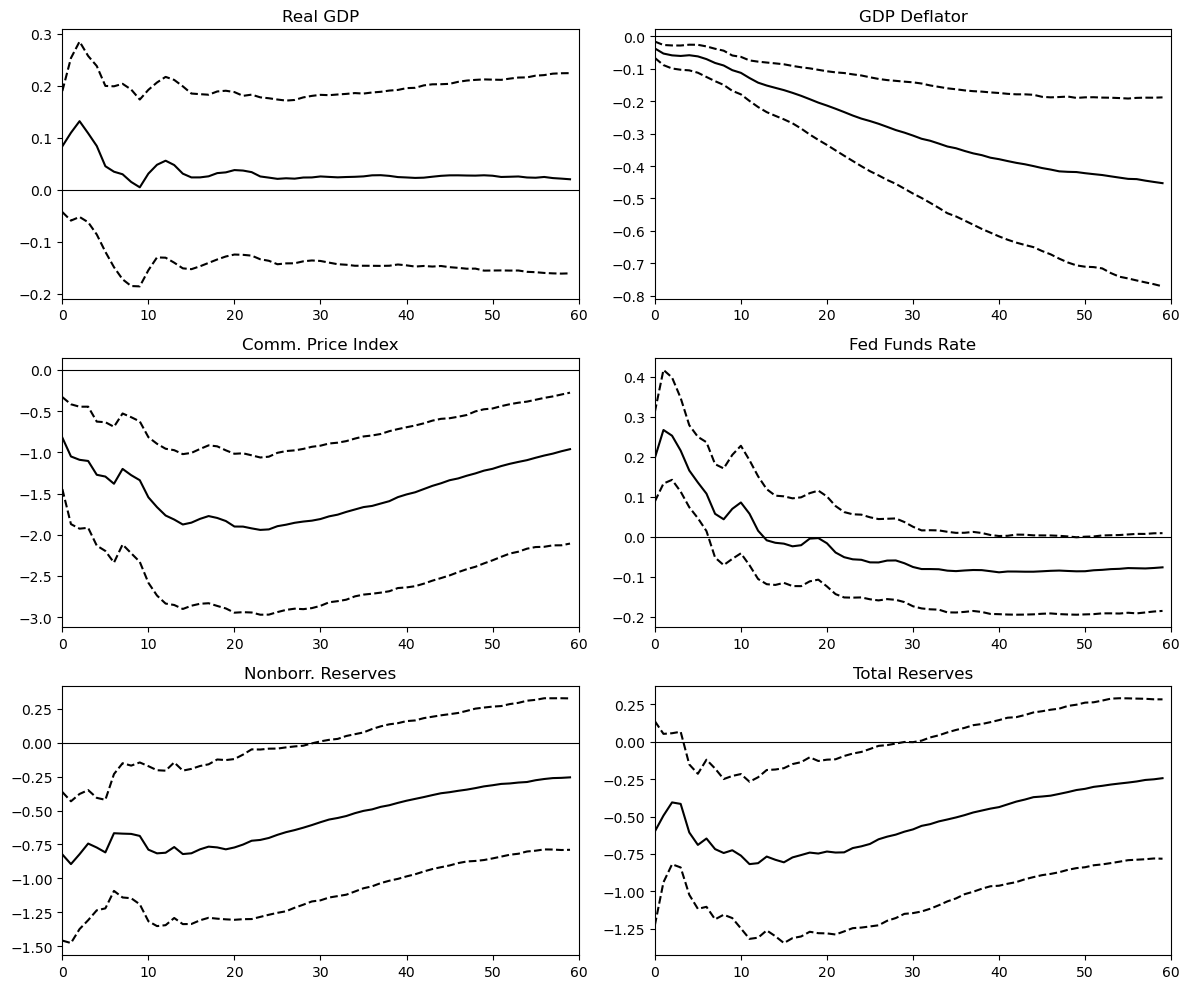

In [2]:
# ==========================================
# 2. REDUCED-FORM VAR AND NUMERICALLY STABILIZED POSTERIOR
# ==========================================
# In Section 2 of the script, we estimate the reduced-form VAR and compute the posterior distribution of the parameters.
# The first three lines compute the OLS estimator for the VAR coefficients (B_hat) and the residuals (U). 
# We then calculate the scale matrix (S_scale) for the inverse Wishart distribution, which is used to draw the covariance matrix of the errors in the Monte Carlo simulation.
# \hat{B} = (X^T X)^{-1} X^T Y is the OLS estimator for the VAR coefficients, where X is the matrix of lagged variables and Y is the matrix of dependent variables.
XX = X.T @ X
XX_inv = np.linalg.inv(XX)
XX_inv = (XX_inv + XX_inv.T) / 2.0  # Perfect symmetry for the Wishart distribution

# As we assume homoskedastic errors, the posterior mean of the regression coefficients is the OLS estimator, which is computed as B_hat = (X^T X)^{-1} X^T Y.
# The second line computes the residuals (U) from the OLS estimation, which are used to calculate the scale matrix for the inverse Wishart distribution.
B_hat = XX_inv @ X.T @ Y
U = Y - X @ B_hat

# This is the scale matrix for the inverse Wishart distribution, which is used to draw the covariance matrix of the errors in the Monte Carlo simulation.
# The scale matrix is the first parameter in the inverse Wishart distribution, and it is computed as U^T U, where U are the residuals from the OLS estimation.
S_scale = U.T @ U
S_scale = (S_scale + S_scale.T) / 2.0 # Perfect symmetry for the Wishart distribution

# ==========================================
# 3. MONTE CARLO SIMULATION
# ==========================================
# Block 3 is the core of the script. To make effective comments, we have to distinguish four sub-blocks within this block. 
# This is where we draw from the posterior distribution 
# of the VAR parameters and compute the impulse response functions (IRFs) for each draw.
# n_keep is the number of valid IRFs we want to collect (it means that we want n_keep number of valid IRFs after all the draws from the posterior distribution), 
# n_steps is the number of periods for which we compute the IRFs, and valid_irfs is a list that will store the valid IRFs that satisfy the sign restrictions.
n_keep = 1000
n_steps = 60
valid_irfs = []

# After setting up the parameters for the Monte Carlo simulation, we print a message to indicate that the local simulation is starting.
print("Local simulation is starting (Numerically stabilized)...")

# The jitter for the Cholesky decomposition is added to handle cases where the matrx XX_inv might be close to singular, 
# which can happen in small samples or with highly correlated regressors.
# This code block attempts to compute the Cholesky decomposition of the inverse of X^T X (XX_inv). If XX_inv is impossible to decompose due to numerical issues 
# (e.g., it is not positive definite), it adds a small jitter (1e-9 times the identity matrix) to ensure that the matrix is 
# positive definite and the Cholesky decomposition can be computed successfully.
# This manipulation is necessary because the Cholesky decomposition requires the input matrix to be positive definite, 
# and in some cases, due to numerical issues, XX_inv might not be perfectly positive definite. By adding a small jitter, we ensure that the decomposition 
# can be performed without errors, allowing us to proceed with the Monte Carlo simulation. This manipulation does NOT distort the results in any meaningful way, 
# as the jitter is extremely small and only serves to ensure numerical stability.
# When we will soon perform the draws for the VAR coefficients, we will need to use the Cholesky factor of XX_inv to 
# transform the standard normal draws into draws that reflect the posterior distribution of the coefficients.
# -----------------------------------------------
# 3.1. Cholesky decomposition of XX_inv with jitter for numerical stability
# -----------------------------------------------
try:
    chol_XX_inv = np.linalg.cholesky(XX_inv)
except np.linalg.LinAlgError:
    chol_XX_inv = np.linalg.cholesky(XX_inv + np.eye(XX_inv.shape[0]) * 1e-9)

draw_count = 0
while len(valid_irfs) < n_keep:
    draw_count += 1
    
    # This is where we draw from the posterior distribution of the covariance matrix of the errors (Omega) using the inverse Wishart distribution.
    Omega_draw = invwishart.rvs(df=T, scale=S_scale)
    

    # The next small block attempts to compute the Cholesky decomposition of the drawn covariance matrix (Omega_draw). 
    # Similar to the previous block, if Omega_draw is not positive definite, we add a small jitter to ensure that the decomposition can be performed successfully.
    # NOTE: Omega_draw is the covariance matrix of the errors for any t, supposed to be costant over the periods, 
    # and we need its Cholesky factor to transform the standard normal draws into draws that reflect the posterior distribution of the errors.
    try:
        chol_Omega = np.linalg.cholesky(Omega_draw)
    except np.linalg.LinAlgError:
        chol_Omega = np.linalg.cholesky(Omega_draw + np.eye(m) * 1e-9)
    
    # -----------------------------------------------
    # 3.2. Drawing from the posterior distribution of the VAR coefficients (B)
    # -----------------------------------------------
    # This is where we draw from the posterior distribution of the VAR coefficients (B). 
    # Under the hood, we draw a standard normal matrix Z_B of the same shape as B_hat, and then we transform it using the Cholesky 
    # factors of XX_inv and Omega_draw to get a draw from the posterior distribution of B.
    # In the line B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Omega.T, we start with the posterior mean (B_hat) and add a 
    # random draw that reflects the uncertainty around this mean, depending on the variability in the data (captured by Omega_draw) 
    # and the precision of the estimates (captured by XX_inv).
    Z_B = np.random.randn(X.shape[1], m)
    B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Omega.T


    

    # ------------------------------------------------
    # 3.3. Constructing the companion form and computing the IRFs
    # ------------------------------------------------
    # In this code block, we construct the companion form of the VAR model using the drawn coefficients (B_draw) 
    # and compute the impulse response functions (IRFs) for each draw. Note that the coefficient matrix B_draw includes the coefficient for p = 12 lags. 
    # Calcuating the IRFs in this structure would be a nightmare, so we simplify the system into a gigantic VAR(1) system, which is called the companion form.
    # This companion form is matrix Gamma, which is a block matrix that contains the coefficients of the VAR model in a way that allows us to compute the IRFs easily.
    B_ar = B_draw[:-1, :]
    Gamma = np.zeros((m * p, m * p))
    Gamma[:m, :] = B_ar.T
    Gamma[m:, :-m] = np.eye(m * (p - 1))
    
    # This is the selection matrix J, which is used to extract the relevant parts of the IRFs from the companion form.
    J = np.zeros((m, m * p))
    J[:m, :m] = np.eye(m)
    

    # This block computes the IRFs for n_steps periods using the companion form. We initialize a base IRF matrix (irf_base) 
    # and a carry matrix that starts as the identity matrix. The role of the carry matrix is to keep track of the 
    # cumulative effect of the shocks as we iterate through the periods.
    # Note that in the code below, chol_Omega is the Cholesky factor of the drawn covariance matrix of the errors. An irf_base is computed for each period k, 
    # which captures the response of the system to a shock in the first period, and then we update the carry matrix by multiplying it with the companion matrix 
    # Gamma to get the cumulative effect for the next period. This way, we can compute the IRFs for all n_steps periods efficiently.
    # We have to apply J twice in the computation of irf_base to extract the relevant parts of the IRFs from the companion form, and we multiply by chol_Omega to 
    # incorporate the scale of the shocks as determined by the drawn covariance matrix.
    irf_base = np.zeros((n_steps, m, m))
    carry = np.eye(m * p)
    for k in range(n_steps):
        # This is the part where we calculate the k-power of the companion matrix (Gamma) and use it to compute the IRF for period k. 
        # The IRF is computed as J @ carry @ J.T @ chol_Omega,
        # where carry is the cumulative effect of the shocks up to period k, and J is the selection matrix that extracts the relevant parts of the IRF from the companion form. 
        # The matrix carry is constructed just to "remember" the result of the previous multiplications with Gamma, 
        # so we can efficiently compute the IRFs for all periods without having to recompute the powers of Gamma from scratch each time.
        irf_base[k] = J @ carry @ J.T @ chol_Omega
        carry = carry @ Gamma

    # This is the part in the code where we finalize the computation of the IRFs by multiplying the Cholesky factor from the right with a vector alpha, 
    # which is drawn from the unit sphere. This step is crucial for imposing the sign restrictions on the IRFs. In Uhlig (2005), chol_Omega @ alpha represents 
    # a linear combination of the structural shocks, and by varying alpha, we can explore different combinations of shocks to find those that satisfy the sign restrictions.
    # In Uhlig's parlance, a = chol_Omega @ alpha is an impulse vector that represents a particular structural shock, and by changing alpha, 
    # we can generate different impulse vectors.
    for _ in range(100):
        alpha = np.random.randn(m)
        alpha = alpha / np.linalg.norm(alpha)
        
        candidate_irf = irf_base @ alpha
        
        # ------------------------------------------------
        # 3.4. Checking the sign restrictions on the candidate IRF
        # ------------------------------------------------
        # This is the part where we check the sign restrictions on the candidate IRF.
        # This is an easy but effective trick to ensure that the sign restrictions are satisfied for the same shock across all periods in the horizon.
        # If the draw for the shock leads to a negative response in the federal funds rate (the fourth variable in our ordering) in the first period, 
        # we don't drop the draw but flip the sign of the entire IRF - this way, we can make the algorithm more efficient by not having to discard draws 
        # that are just the "mirror image" of valid IRFs.
        # The code candidate_irf[0, 3] < 0 as a slice picks the response of the federal funds rate to the shock in the first period 
        # (the first row of candidate_irf corresponds to the first period, and the fourth column corresponds to the federal funds rate).
        if candidate_irf[0, 3] < 0:
            candidate_irf = -candidate_irf
            
        horizon = candidate_irf[:6, :]
        
        if (np.all(horizon[:, 1] <= 0) and # This is the sign restriction for the GDP deflator, which is the second variable in our ordering. 
            # We want the response of the GDP deflator to be non-positive (prices should not increase) for all periods in the horizon.
            np.all(horizon[:, 2] <= 0) and # This is the sign restriction for the commodity price index, which is the third variable in our ordering. 
            #We want the response of the commodity price index to be non-positive (prices should not increase) for all periods in the horizon.
            np.all(horizon[:, 3] >= 0) and # This is the sign restriction for the federal funds rate, which is the fourth variable in our ordering. 
            # We want the response of the federal funds rate to be non-negative (interest rates should not decrease) for all periods in the horizon.
            np.all(horizon[:, 4] <= 0)): # This is the sign restriction for the non-borrowed reserves, which is the fifth variable in our ordering. 
            # We want the response of the non-borrowed reserves to be non-positive (reserves should not increase) for all periods in the horizon.
            
            # This is the part where we add the candidate IRF to the list of valid IRFs if it satisfies the sign restrictions. 
            # We also print a message every 100 valid IRFs collected to track the progress of the simulation.
            valid_irfs.append(candidate_irf)
            if len(valid_irfs) % 100 == 0:
                print(f"Success! {len(valid_irfs)} / {n_keep} valid IRFs collected.", flush=True)
            break

print(f"\nSuccess! {draw_count} posterior draws yielded {n_keep} valid IRFs.")

# ==========================================
# 4. RESULTS PLOTTING
# ==========================================
# This part is not complicated. We simply compute the 16th, 50th, and 84th percentiles of the valid IRFs across all draws to get 
# the median and the confidence intervals for the IRFs.
valid_irfs = np.array(valid_irfs)
irf_16 = np.percentile(valid_irfs, 16, axis=0)
irf_50 = np.percentile(valid_irfs, 50, axis=0)
irf_84 = np.percentile(valid_irfs, 84, axis=0)

var_names = ['Real GDP', 'GDP Deflator', 'Comm. Price Index', 'Fed Funds Rate', 'Nonborr. Reserves', 'Total Reserves']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
x = np.arange(60)

for i in range(6):
    axes[i].plot(x, irf_50[:, i], 'k-', label='Median')
    axes[i].plot(x, irf_16[:, i], 'k--')
    axes[i].plot(x, irf_84[:, i], 'k--')
    axes[i].axhline(0, color='k', linewidth=0.8)
    axes[i].set_title(var_names[i])
    axes[i].set_xlim([0, 60])

plt.tight_layout()
# save the figure as Uhlig_Fig6.jpg
plt.savefig('Uhlig_Fig6.jpg', dpi=300)
plt.show()

Starting the simulation (computing IRFs and FEVDs)...
Success! 100 / 1000 valid IRFs collected.
Success! 200 / 1000 valid IRFs collected.
Success! 300 / 1000 valid IRFs collected.
Success! 400 / 1000 valid IRFs collected.
Success! 500 / 1000 valid IRFs collected.
Success! 600 / 1000 valid IRFs collected.
Success! 700 / 1000 valid IRFs collected.
Success! 800 / 1000 valid IRFs collected.
Success! 900 / 1000 valid IRFs collected.
Success! 1000 / 1000 valid IRFs collected.

Success! 1004 posterior draws yielded 1000 valid IRFs.

Forecast Error Variance Decomposition (FEVD) - Median (%)
--------------------------------------------------------------------------------
    Real GDP  GDP Deflator  Comm. Price Index  Fed Funds Rate  \
1       9.24         10.92              10.39           18.39   
10      8.05         11.72              13.22           10.96   
20      8.62         13.64              17.50            8.46   
30      7.96         14.86              20.83            8.77   
40  

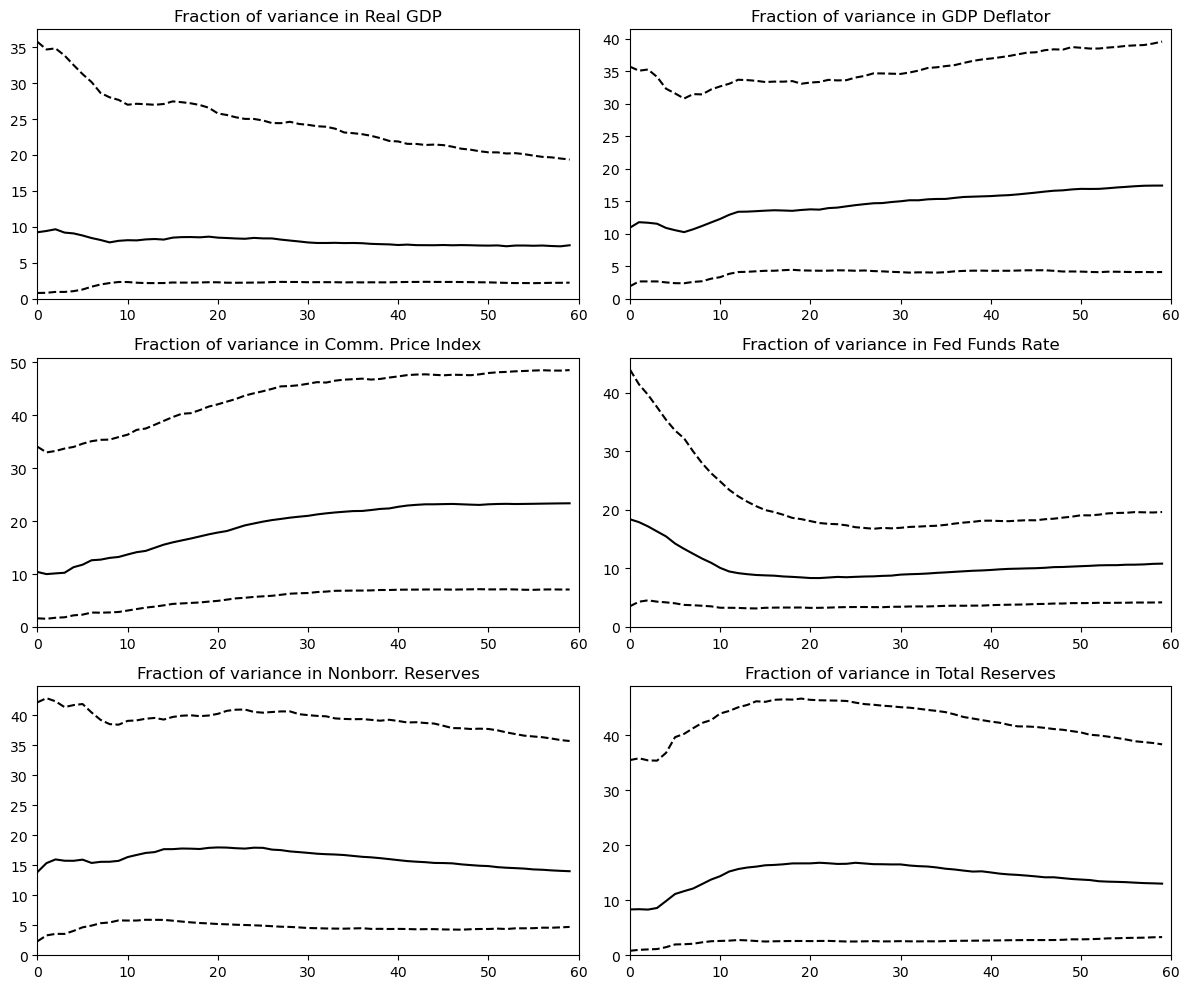

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart

# ====================================================================================
# 1. DATA PREPARATION FOR THE LOCAL ENVIRONMENT: Reproducing Uhlig's (2005) Fig.8.
# ====================================================================================
# This is the very same procedure as in the previous section for IRFs, where we import the data, take logarithms of the relevant variables, 
# and construct the matrices for the VAR model.
filepath = 'uhligdata.xls'
df = pd.read_excel(filepath).dropna()


cols_to_log = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'BOGNONBR', 'TOTRESNS']
for col in cols_to_log:
    df[col] = np.log(df[col]) * 100

ordered_cols = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'FEDFUNDS', 'BOGNONBR', 'TOTRESNS']
Y_raw = df[ordered_cols].values

p = 12
T_raw, m = Y_raw.shape
T = T_raw - p
Y = Y_raw[p:]
X = np.zeros((T, m * p))
for i in range(p):
    X[:, i*m : (i+1)*m] = Y_raw[p - i - 1 : T_raw - i - 1]

X = np.hstack([X, np.ones((T, 1))])

# ==========================================
# 2. REDUCED-RANK VAR & NUMERICAL STABILIZATION
# ==========================================
# Again, this is the same procedure as in the previous section for IRFs, where we estimate the reduced-form VAR and compute the posterior distribution of the parameters.
XX = X.T @ X
XX_inv = np.linalg.inv(XX)
XX_inv = (XX_inv + XX_inv.T) / 2.0 

B_hat = XX_inv @ X.T @ Y
U = Y - X @ B_hat

S_scale = U.T @ U
S_scale = (S_scale + S_scale.T) / 2.0 

# ==========================================
# 3. MONTE CARLO SIMULATION (IRF and FEVD)
# ==========================================
# In this block, we perform the Monte Carlo simulation to draw from the posterior distribution of the VAR parameters, compute the IRFs, and check the sign restrictions.
# We also compute the forecast error variance decomposition (FEVD) for the valid IRFs that satisfy the sign restrictions. 
n_keep = 1000
n_steps = 60
valid_irfs = []
valid_fevds = []

print("Starting the simulation (computing IRFs and FEVDs)...")

try:
    chol_XX_inv = np.linalg.cholesky(XX_inv)
except np.linalg.LinAlgError:
    chol_XX_inv = np.linalg.cholesky(XX_inv + np.eye(XX_inv.shape[0]) * 1e-9)

draw_count = 0
while len(valid_irfs) < n_keep:
    draw_count += 1
    
    Sigma_draw = invwishart.rvs(df=T, scale=S_scale)
    
    try:
        chol_Sigma = np.linalg.cholesky(Sigma_draw)
    except np.linalg.LinAlgError:
        chol_Sigma = np.linalg.cholesky(Sigma_draw + np.eye(m) * 1e-9)
    
    Z_B = np.random.randn(X.shape[1], m)
    B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Sigma.T
    
    B_ar = B_draw[:-1, :]
    Gamma = np.zeros((m * p, m * p))
    Gamma[:m, :] = B_ar.T
    Gamma[m:, :-m] = np.eye(m * (p - 1))
    
    J = np.zeros((m, m * p))
    J[:m, :m] = np.eye(m)
    
    irf_base = np.zeros((n_steps, m, m))
    carry = np.eye(m * p)
    for k in range(n_steps):
        irf_base[k] = J @ carry @ J.T @ chol_Sigma
        carry = carry @ Gamma
        
    for _ in range(100):
        alpha = np.random.randn(m)
        alpha = alpha / np.linalg.norm(alpha)
        
        candidate_irf = irf_base @ alpha
        
        if candidate_irf[0, 3] < 0:
            candidate_irf = -candidate_irf
            
        horizon = candidate_irf[:6, :]
        
        if (np.all(horizon[:, 1] <= 0) and 
            np.all(horizon[:, 2] <= 0) and 
            np.all(horizon[:, 3] >= 0) and 
            np.all(horizon[:, 4] <= 0)):
            
            valid_irfs.append(candidate_irf)
            # Up to this point, the code is the same as in the previous section for IRFs, where we check the sign restrictions and collect valid IRFs.
            # -----------------------------------------------------------------------------------------------------------------
            # Computing and storing the FEVD for the valid IRFs. The FEVD is computed as the cumulative sum of the squared candidate IRFs divided 
            # by the cumulative sum of the total variance (which is the sum of the squared IRFs across all shocks). Calculation is based on Uhlig's (2005)
            # last formula on p. 387. The first line in this block is the numerator of the FEVD (i.e. Uhlig's formula on p. 387), 
            # which describes the square of the IRF (as a squared difference or VARIANCE) for the variable j at lag k when assuming the impulse vector "a" 
            # (which is chol_Omega @ alpha in our code - that we keep drawing) that satisfies the sign restrictions. The second line is the denominator of the FEVD, 
            # which describes the total variance of the forecast error for variable j at horizon k, 
            # which is the sum of the squared IRFs across all kinds of shocks when we assume the impulse vector "a". Hence, the denominator describes the total 
            # variance of forecast errors for variable j at horizon k, triggered by all kinds of shocks. Hence, the ratio of the two (multiplied by 100 to get percentage terms) 
            # gives us the fraction of the forecast error variance for variable j at horizon k that can be attributed to the shock we are investigating.
            var_identified = np.cumsum(candidate_irf**2, axis=0)
            var_total = np.cumsum(np.sum(irf_base**2, axis=2), axis=0)
            
            # This is the part where we compute the FEVD for the valid IRF and store it in the list of valid FEVDs. 
            # We compute the FEVD as the ratio of the variance attributed to the identified shock. 
            fevd = (var_identified / var_total) * 100
            valid_fevds.append(fevd)
            
            if len(valid_irfs) % 100 == 0:
                print(f"Success! {len(valid_irfs)} / {n_keep} valid IRFs collected.", flush=True)
            break

print(f"\nSuccess! {draw_count} posterior draws yielded {n_keep} valid IRFs.")

# ==========================================
# 4. FEVD TABLE CREATION AND PLOTTING
# ==========================================
var_names = ['Real GDP', 'GDP Deflator', 'Comm. Price Index', 'Fed Funds Rate', 'Nonborr. Reserves', 'Total Reserves']

valid_fevds = np.array(valid_fevds)
fevd_50 = np.percentile(valid_fevds, 50, axis=0)

horizons = [1, 10, 20, 30, 40, 50, 60]
indices = [h - 1 for h in horizons]

fevd_table = pd.DataFrame(
    fevd_50[indices, :], 
    columns=var_names, 
    index=horizons
)

print("\nForecast Error Variance Decomposition (FEVD) - Median (%)")
print("-" * 80)
print(fevd_table.round(2))
print("-" * 80)

# ==========================================
# 5. DRAWING UHLIG'S FIG. 8 - FEVD
# ==========================================
# In this part, we draw Uhlig's Fig. 8, which shows the FEVD for each variable over the 60-month horizon. 
# We plot the median FEVD along with the 16th and 84th percentiles to show the uncertainty around the estimates.
fevd_16 = np.percentile(valid_fevds, 16, axis=0)
fevd_84 = np.percentile(valid_fevds, 84, axis=0)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
x = np.arange(60)

for i in range(6):
    axes[i].plot(x, fevd_50[:, i], 'k-', label='Median')
    axes[i].plot(x, fevd_16[:, i], 'k--')
    axes[i].plot(x, fevd_84[:, i], 'k--')
    axes[i].set_ylim(bottom=0)  # A variancia nem lehet negatív
    axes[i].set_title(f"Fraction of variance in {var_names[i]}")
    axes[i].set_xlim([0, 60])

plt.tight_layout()
# Save the figure as Uhlig_Fig8.jpg
plt.savefig('Uhlig_Fig8.jpg', dpi=300)
plt.show()